# Empirical predictions — expected-sign matrix

Codify Rindi deck tables **pp. 20–29** into `ticksize.expected_sign_matrix`, then score crypto MQ signs on the ETH HL+Deribit+Kraken slice.

Sign convention: spreads **+1 = tighten**; depth/volume **+1 = increase**; **0 = ambiguous / Kill**.
LOB undercutting story stays in NOTES — no production game sim.


## Setup


In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

ROOT = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure"))
sys.path.insert(0, str(ROOT))
from research.lib import ticksize

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / 'research' / 'books' / 'mm_confr_viewpoints'
PASS1 = BOOK / 'out' / 'pass1'
PASS2 = BOOK / 'out' / 'pass2'
FIGS = BOOK / 'out' / 'emp_predictions' / 'figs'

emat = json.loads((PASS1 / 'expected_sign_matrix.json').read_text())
score = json.loads((PASS1 / 'sign_scorecard.json').read_text())
hard = json.loads((PASS2 / 'hardening_gates.json').read_text())

lib_mat = ticksize.expected_sign_matrix()
print('artifact source:', emat.get('source'))
print('kill_metrics:', emat.get('kill_metrics'))
print('lib matrix type', type(lib_mat).__name__, 'n' if hasattr(lib_mat, '__len__') else '', len(lib_mat) if hasattr(lib_mat, '__len__') else '')
print('scorecard summary:', score.get('scorecard'))


artifact source: Rindi et al. MMCV#3 2014 slides pp.20–29
kill_metrics: ['welfare']
lib matrix type dict n 5
scorecard summary: {'hits': 1, 'misses': 2, 'skips': 1, 'hit_rate': 0.3333333333333333, 'detail': [{'regime': 'rel_tick_up', 'metric': 'relative_spread', 'book': 'any', 'obs_sign': 1, 'rho': -0.6, 'n': 9, 'expected': -1, 'match': False}, {'regime': 'rel_tick_up', 'metric': 'quoted_spread', 'book': 'any', 'obs_sign': 1, 'rho': -0.6, 'n': 9, 'expected': 0, 'match': None}, {'regime': 'rel_tick_up', 'metric': 'bbo_depth', 'book': 'any', 'obs_sign': -1, 'rho': -0.7142857142857143, 'n': 6, 'expected': 1, 'match': False}, {'regime': 'rel_tick_up', 'metric': 'volume', 'book': 'any', 'obs_sign': -1, 'rho': -0.6, 'n': 9, 'expected': -1, 'match': True}]}


## Expected-sign heatmap (deck)

Liquid vs less-liquid columns. **Welfare column marked KILL** (unobservable on crypto desk).


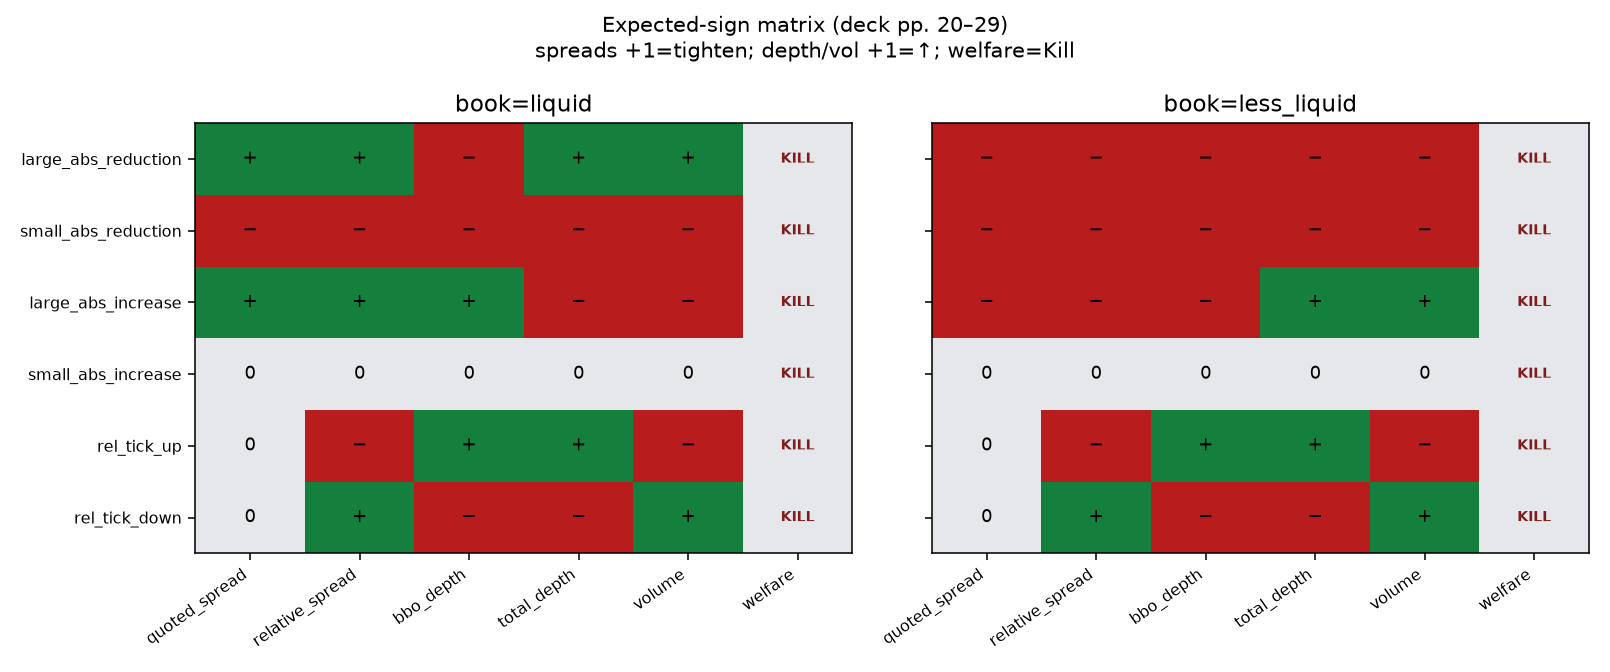

n_cells 72 kill cells 12
             regime        book          metric  sign  kill
large_abs_reduction      liquid   quoted_spread     1 False
large_abs_reduction      liquid relative_spread     1 False
large_abs_reduction      liquid       bbo_depth    -1 False
large_abs_reduction      liquid     total_depth     1 False
large_abs_reduction      liquid          volume     1 False
large_abs_reduction      liquid         welfare     0  True
large_abs_reduction less_liquid   quoted_spread    -1 False
large_abs_reduction less_liquid relative_spread    -1 False
large_abs_reduction less_liquid       bbo_depth    -1 False
large_abs_reduction less_liquid     total_depth    -1 False
large_abs_reduction less_liquid          volume    -1 False
large_abs_reduction less_liquid         welfare     0  True
        rel_tick_up      liquid   quoted_spread     0 False
        rel_tick_up      liquid relative_spread    -1 False
        rel_tick_up      liquid       bbo_depth     1 False
        rel_tic

In [2]:
display(Image(filename=str(FIGS / 'fig_sign_heatmap.png')))
rows = []
for regime, books in emat['matrix'].items():
    for book, mets in books.items():
        for metric, sign in mets.items():
            rows.append({
                'regime': regime, 'book': book, 'metric': metric, 'sign': sign,
                'kill': metric in (emat.get('kill_metrics') or []),
            })
mdf = pd.DataFrame(rows)
print('n_cells', len(mdf), 'kill cells', int(mdf['kill'].sum()))
print(mdf[mdf.regime.isin(['rel_tick_up', 'large_abs_reduction'])].to_string(index=False))


## Empirical scorecard vs deck (`rel_tick_up`)

Cross-section Spearman of MQ vs relative tick on complete venue-days; compare observed sign to deck expected sign.


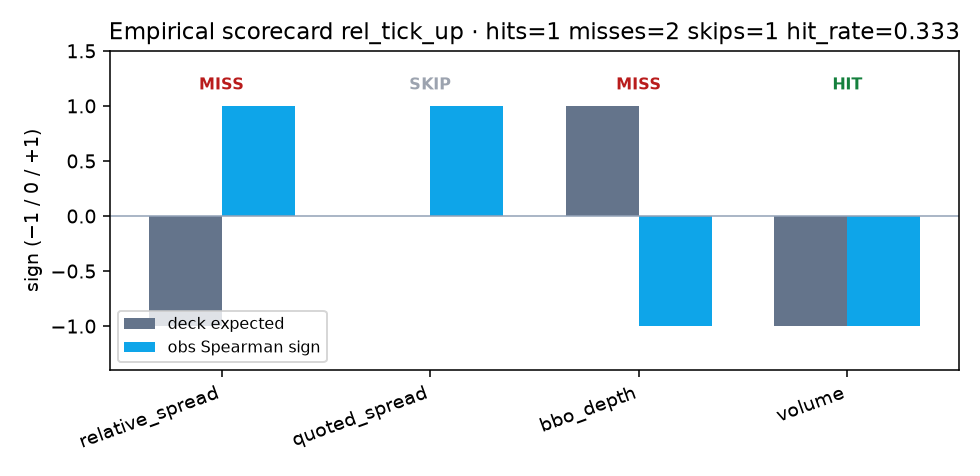

,regime,metric,book,obs_sign,rho,n,expected,match
0,rel_tick_up,relative_spread,any,1,-0.600000,9,-1,False
1,rel_tick_up,quoted_spread,any,1,-0.600000,9,0,None
2,rel_tick_up,bbo_depth,any,-1,-0.714286,6,1,False
3,rel_tick_up,volume,any,-1,-0.600000,9,-1,True


hits=1 misses=2 skips=1 hit_rate=0.333
rho CI (hardening): {'point': -0.6, 'lo': -0.9166666666666666, 'hi': 0.24208333333333296, 'n': 9}
  relative_spread rho -0.6 obs_sign 1 expected -1 match False
  quoted_spread rho -0.6 obs_sign 1 expected 0 match None
  bbo_depth rho -0.714 obs_sign -1 expected 1 match False
  volume rho -0.6 obs_sign -1 expected -1 match True


In [3]:
display(Image(filename=str(FIGS / 'fig_scorecard.png')))
detail = pd.DataFrame(score['scorecard']['detail'])
display(detail)
sc = score['scorecard']
print('hits={} misses={} skips={} hit_rate={:.3f}'.format(
    sc['hits'], sc['misses'], sc['skips'], sc['hit_rate']))
print('rho CI (hardening):', hard.get('rho_ci'))
for d in score['scorecard']['detail']:
    print(' ', d['metric'], 'rho', round(d['rho'], 3),
          'obs_sign', d['obs_sign'], 'expected', d['expected'], 'match', d['match'])


## Kill cells called out

| Cell / ID | Why Kill |
|-----------|----------|
| `welfare` (all regimes×books) | Unobservable prefs |
| `id.sec_ipo_channel` | Out of scope |
| `id.lse_nasdaq_rdd_literal` | No sovereign tick ladder |
| `disc.sign_scorecard_tradable` | hit_rate too low / fragile — not tradable |


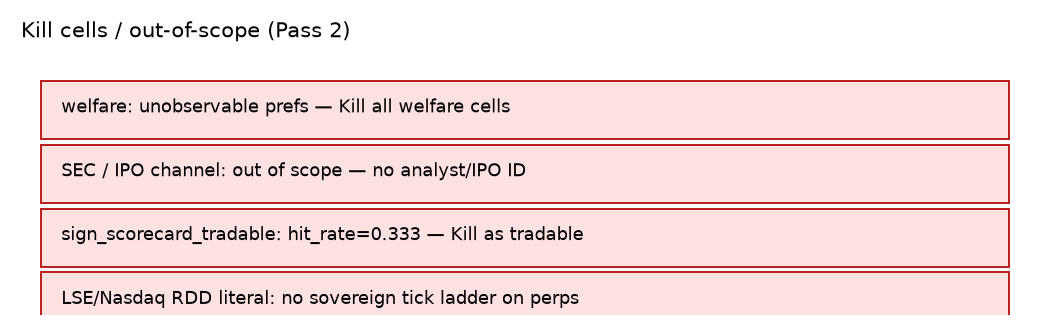

id.welfare_tick                  Kill     unobservable
id.sec_ipo_channel               Kill     out of scope
id.lse_nasdaq_rdd_literal        Kill     no sovereign tick ladder / vanity RD
disc.sign_scorecard_tradable     Kill     hit_rate=0.3333333333333333 on ETH slice; not a tradable signal
disc.expected_sign_matrix        Hold     codified pp.20–29; crypto scorecard hit_rate=0.3333333333333333 n=9
mm.mq_vector -> Hold (L0 total_depth = BBO only on thin TOB)


In [4]:
display(Image(filename=str(FIGS / 'fig_kill_cells.png')))
for cid in [
    'id.welfare_tick', 'id.sec_ipo_channel', 'id.lse_nasdaq_rdd_literal',
    'disc.sign_scorecard_tradable', 'disc.expected_sign_matrix',
]:
    g = (hard.get('gates') or {}).get(cid)
    if g:
        print('{:32s} {:8s} {}'.format(cid, g['decision'], g['why']))
    else:
        print('{:32s} (see CANDIDATES)'.format(cid))
print('mm.mq_vector -> Hold (L0 total_depth = BBO only on thin TOB)')


## LOB undercutting story (NOTES only)

Deck pp. 21–24: large absolute tick reduction on **liquid** books enables undercutting at the BBO (MO→LO → MQ↑ / volume↑). On **less-liquid** books fear of being undercut → LO→MO → MQ deteriorates. Small reductions: price improvement from LO < execution-probability loss → no undercutting. **Do not** ship a production LOB game sim from this package.


## Inline: rebuild sign matrix from lib + scorecard table


lib expected_sign(rel_tick_up, any): {'quoted_spread': 0, 'relative_spread': -1, 'bbo_depth': 1, 'total_depth': 1, 'volume': -1, 'welfare': 0}


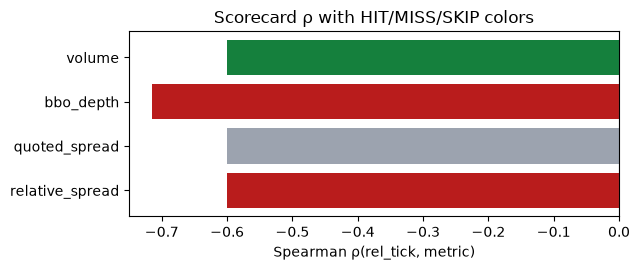

         metric       rho  obs_sign  expected match
relative_spread -0.600000         1        -1 False
  quoted_spread -0.600000         1         0  None
      bbo_depth -0.714286        -1         1 False
         volume -0.600000        -1        -1  True
Kill welfare cells: 12 / 72


In [5]:
import matplotlib.pyplot as plt

# Prefer artifact matrix; also show lib expected_sign for rel_tick_up
metrics = ['quoted_spread', 'relative_spread', 'bbo_depth', 'total_depth', 'volume', 'welfare']
lib_row = {m: ticksize.expected_sign('rel_tick_up', m, book='any') for m in metrics}
print('lib expected_sign(rel_tick_up, any):', lib_row)

fig, ax = plt.subplots(figsize=(6.5, 2.8))
detail = score['scorecard']['detail']
labs = [d['metric'] for d in detail]
rhos = [d['rho'] for d in detail]
cols = ['#15803d' if d['match'] is True else ('#b91c1c' if d['match'] is False else '#9ca3af') for d in detail]
ax.barh(labs, rhos, color=cols)
ax.axvline(0, color='#94a3b8', lw=0.8)
ax.set_xlabel('Spearman ρ(rel_tick, metric)')
ax.set_title('Scorecard ρ with HIT/MISS/SKIP colors')
fig.tight_layout(); plt.show()

print(pd.DataFrame(detail)[['metric','rho','obs_sign','expected','match']].to_string(index=False))
print('Kill welfare cells:', sum(1 for r in mdf.itertuples() if r.kill), '/', len(mdf))


## Promote / Hold / Kill

| ID | Decision | Falsifier |
|----|----------|-----------|
| `disc.expected_sign_matrix` | **Hold** | crypto hit_rate=0.333 on n=9 |
| `mm.mq_vector` | **Hold** | L0 total_depth ≈ BBO on thin TOB |
| `id.welfare_tick` | **Kill** | unobservable |
| `id.sec_ipo_channel` | **Kill** | out of scope |
| `disc.sign_scorecard_tradable` | **Kill** | hit_rate fragile / not tradable |
